In [1]:
# =====================================================
# A) common_h2.py  (SHARED BY ALL METHODS) — notebook-friendly
# This version is aligned 1:1 with your RBC constants/disturbances/KPIs.
# =====================================================

import numpy as np

# -------------------------
# 1) Time settings
# -------------------------
CONTROL_HORIZON = 1
PREDICTION_HORIZON = 12
T_TOTAL = 168  # 1 week, 1-hour steps
DT_HOURS = 1.0

# -------------------------
# 2) System parameters (physical)  [MATCH RBC]
# -------------------------
ETA_CH = 0.95
ETA_DCH = 0.95

KWH_PER_KG = 50.0                 # ~48–55 kWh/kg typical
ETA_ELEC = (DT_HOURS / KWH_PER_KG)  # kg per timestep per kW (1kW*1h=1kWh)

SOC_MAX = 1000.0   # kWh
P_BAT_MAX = 200.0  # kW
P_ELEC_MAX = 300.0 # kW
H_STORE_MAX = 1000.0  # kg

# Hydrogen storage throughput (kg/h)
H_CH_MAX = 10.0
H_DCH_MAX = 10.0

# Electrolyzer operational constraints
P_ELEC_MIN = 0.2 * P_ELEC_MAX  # kW
RAMP_MAX = 60.0                # kW per hour

# Grid import limit (kW)
P_GRID_MAX = 250.0

# -------------------------
# 3) Economics (units aligned)  [MATCH RBC]
# -------------------------
# prices are in $/kWh and $/kg
C_GRID_BASE = 40.0      # (can be removed if unused)
C_BATTERY = 0.03        # $/kWh throughput (charge+discharge)
C_ELEC = 0.01           # $/kWh electricity input
C_HSTORE = 0.0005       # $/(kg·hour)

H_PRICE = 10.0          # $/kg
CO2_ADDER = 0.02        # $/kWh (carbon adder)

# -------------------------
# 4) Initial states  [MATCH RBC]
# -------------------------
SOC_INIT = 500.0
H_STORE_INIT = 20.0

# -------------------------
# 5) RNGs for disturbances (DO NOT re-init inside functions)  [MATCH RBC]
# -------------------------
_SOLAR_RNG = np.random.default_rng(0)
_PRICE_RNG = np.random.default_rng(1)
_DEMAND_RNG = np.random.default_rng(2)

# -------------------------
# 6) Real-time disturbance models (truth signals)  [MATCH RBC]
# -------------------------
def real_solar(t: int) -> float:
    """
    PV power available at time t [kW].
    Day/night half-sine + slow cloudiness + small noise.
    """
    hod = t % 24
    if hod < 6 or hod > 18:
        base = 0.0
    else:
        x = (hod - 6) / 12.0
        base = np.sin(np.pi * x)

    P_PV_PEAK = 300
    day = t // 24
    cloud = 0.75 + 0.20 * np.sin(2*np.pi*day/7.0)
    noise = _SOLAR_RNG.normal(0.0, 0.03)

    return float(max(0.0, P_PV_PEAK * base * (cloud + noise)))

def real_grid_price(t: int) -> float:
    """
    Electricity price [$/kWh].
    Time-of-use + rare spikes.
    """
    hod = t % 24
    if 0 <= hod < 6:
        p = 0.08
    elif 6 <= hod < 16:
        p = 0.12
    elif 16 <= hod < 21:
        p = 0.28
    else:
        p = 0.15

    # 2% spike chance
    if _PRICE_RNG.random() < 0.02:
        p *= 2.5

    return float(p)

def real_hydrogen_demand(t: int) -> float:
    """
    Hydrogen demand [kg/h] at time t.
    Scaled to match 300 kW electrolyzer (~6 kg/h max).
    """
    hod = t % 24
    base = 3.5 + 1.5*np.sin(2*np.pi*(hod-8)/24.0)  # ~2..5
    day = t // 24
    weekly = 0.3*np.sin(2*np.pi*day/7.0)
    noise = _DEMAND_RNG.normal(0.0, 0.25)

    return float(max(0.0, base + weekly + noise))

# -------------------------
# 7) Forecast model (used by MPC and RL+Forecast)  [MATCH RBC]
# -------------------------
SIGMA_SOLAR0 = 10.0   # kW
SIGMA_PRICE0 = 0.02   # $/kWh
SIGMA_DEMAND0 = 0.5   # kg/h
ALPHA = 0.8

def forecast_with_uncertainty(real_func, t_now: int, delta: int, rng: np.random.Generator, sigma0: float):
    """
    Forecast for time t_now+delta with uncertainty increasing in delta.
    """
    std = float(sigma0 * np.sqrt(1.0 + ALPHA * float(delta)))
    value = float(real_func(t_now + delta) + rng.normal(0.0, std))
    return value, std

# -------------------------
# 8) Common logger + KPI tools  [MATCH RBC]
# -------------------------
def init_logs():
    """
    Standardized logging schema used by all methods.
    Keys MUST match across RBC/MPC/RL for apples-to-apples KPI computation.
    """
    return {k: [] for k in [
        "E_sb","E_sp","E_be","E_ge","P_elec",
        "H_prod","H_sales","H_es","H_est","H_ss",
        "SOC","H_store","solar"
    ]}

def compute_kpis(logs: dict) -> dict:
    """
    Compute standardized KPIs from logs (same for RBC, MPC, RL).
    Assumes logs contain T steps for decision variables and pre-update states.
    """
    time = np.arange(len(logs["E_sb"]))

    E_sb = np.asarray(logs["E_sb"], dtype=float)
    E_be = np.asarray(logs["E_be"], dtype=float)
    E_ge = np.asarray(logs["E_ge"], dtype=float)
    P_elec = np.asarray(logs["P_elec"], dtype=float)

    H_prod = np.asarray(logs["H_prod"], dtype=float)
    H_sales = np.asarray(logs["H_sales"], dtype=float)
    H_es = np.asarray(logs["H_es"], dtype=float)
    H_est = np.asarray(logs["H_est"], dtype=float)
    H_ss = np.asarray(logs["H_ss"], dtype=float)

    H_store = np.asarray(logs["H_store"], dtype=float)

    # ENERGY METRICS
    solar_to_battery = float(np.sum(E_sb))
    solar_to_electrolyzer = float(np.sum(P_elec - E_be - E_ge))
    battery_discharge = float(np.sum(E_be))
    grid_energy = float(np.sum(E_ge))
    electrolyzer_energy = float(np.sum(P_elec))

    # HYDROGEN METRICS
    hydrogen_produced = float(np.sum(H_prod))
    hydrogen_sold_total = float(np.sum(H_sales))
    hydrogen_sold_from_prod = float(np.sum(H_es))
    hydrogen_sold_from_storage = float(np.sum(H_ss))
    hydrogen_to_storage = float(np.sum(H_est))

    # COSTS
    grid_prices = np.array([real_grid_price(int(t)) for t in time], dtype=float)
    grid_cost = float(np.sum(E_ge * (grid_prices + CO2_ADDER)))
    battery_cost = float(np.sum(C_BATTERY * (E_sb + E_be)))
    electrolyzer_cost = float(np.sum(C_ELEC * P_elec))
    storage_cost = float(np.sum(C_HSTORE * H_store))
    total_cost = float(grid_cost + battery_cost + electrolyzer_cost + storage_cost)

    # REVENUE & PROFIT
    revenue = float(np.sum(H_PRICE * H_sales))
    net_profit = float(revenue - total_cost)

    kpis = {
        # Energy
        "Solar Used (E_se)": solar_to_electrolyzer,
        "Grid Energy Used (E_ge)": grid_energy,
        "Battery Charge (E_sb)": solar_to_battery,
        "Battery Discharge (E_be)": battery_discharge,
        "Electrolyzer Energy": electrolyzer_energy,

        # Hydrogen
        "Hydrogen Produced": hydrogen_produced,
        "Hydrogen Sold (Total)": hydrogen_sold_total,
        "Hydrogen Sold from Production (H_es)": hydrogen_sold_from_prod,
        "Hydrogen Sold from Storage (H_ss)": hydrogen_sold_from_storage,
        "Hydrogen Stored (H_est)": hydrogen_to_storage,

        # Economics
        "Revenue ($)": revenue,
        "Grid Cost ($)": grid_cost,
        "Battery Cost ($)": battery_cost,
        "Electrolyzer Cost ($)": electrolyzer_cost,
        "Storage Cost ($)": storage_cost,
        "Total Cost ($)": total_cost,
        "Net Profit ($)": net_profit,

        # Efficiency (same as your RBC KPI)
        "H₂ Utilization (%)": float(100 * hydrogen_sold_total / (hydrogen_produced + H_STORE_INIT)) if hydrogen_produced > 0 else 0.0
    }
    return kpis

def plot_kpis(kpi_values: dict, title_suffix: str = "") -> None:
    """
    Publication-ready KPI plots.
    - Removes efficiency panel
    - Thicker bar outlines (print-friendly)
    - Lighter grid
    - Cleaner numeric annotations
    """

    import matplotlib.pyplot as plt

    # ---- Categories (Efficiency removed) ----
    categories = {
        "Energy (kWh)": [
            "Solar Used (E_se)", "Grid Energy Used (E_ge)",
            "Battery Charge (E_sb)", "Battery Discharge (E_be)",
            "Electrolyzer Energy"
        ],
        "Hydrogen (kg)": [
            "Hydrogen Produced", "Hydrogen Sold (Total)",
            "Hydrogen Sold from Production (H_es)",
            "Hydrogen Sold from Storage (H_ss)",
            "Hydrogen Stored (H_est)"
        ],
        "Cost & Revenue ($)": [
            "Revenue ($)", "Grid Cost ($)", "Battery Cost ($)",
            "Electrolyzer Cost ($)", "Storage Cost ($)",
            "Total Cost ($)", "Net Profit ($)"
        ]
    }

    # More compact than the original (but still readable in papers)
    fig, axs = plt.subplots(len(categories), 1, figsize=(13, 14))
    if len(categories) == 1:
        axs = [axs]

    for ax, (title, keys) in zip(axs, categories.items()):
        # robust casting (and clearer error if a key is missing)
        values = [float(kpi_values[k]) for k in keys]

        bars = ax.barh(
            keys,
            values,
            edgecolor="black",
            linewidth=1.2,   # thicker edges for print clarity
        )

        ax.set_title(f"{title} {title_suffix}".strip(), fontsize=13)
        ax.set_xlabel(title, fontsize=12)

        # Lighter grid (cleaner for publication)
        ax.grid(True, axis="x", linestyle="--", alpha=0.25)
        ax.set_axisbelow(True)

        # Improve readability
        ax.tick_params(axis="y", labelsize=11)
        ax.tick_params(axis="x", labelsize=11)

        # Clean numeric formatting + small x-offset so labels don't sit on bar edge
        xpad = 0.01 * (max(abs(v) for v in values) if values else 1.0)

        for bar in bars:
            width = bar.get_width()

            if abs(width) >= 1000:
                label = f"{width:,.0f}"
            elif abs(width) >= 10:
                label = f"{width:.1f}"
            else:
                label = f"{width:.2f}"

            ax.text(
                width + xpad,
                bar.get_y() + bar.get_height() / 2.0,
                label,
                va="center",
                ha="left" if width >= 0 else "right",
                fontsize=10
            )

    plt.tight_layout()
    plt.show()

In [2]:
# =====================================================
# C) mpc_controller.py  (METHOD 2: MPC) — aligned with RBC constants/constraints
# Fix: add PV curtailment/spill variable to avoid infeasibility when solar > P_BAT_MAX
# =====================================================

import numpy as np
import pyomo.environ as pyo


def build_mpc_model(
    current_time: int,
    soc0: float,
    hstore0: float,
    pprev0: float,
    rng: np.random.Generator,
    horizon: int = PREDICTION_HORIZON
):
    m = pyo.ConcreteModel()
    m.T = pyo.RangeSet(0, horizon - 1)

    # ---- Forecasts (CLIPPED to physical ranges) ----
    solar_hat = {}
    price_hat = {}
    demand_hat = {}

    for t in m.T:
        s, _ = forecast_with_uncertainty(real_solar, current_time, int(t), rng, SIGMA_SOLAR0)
        p, _ = forecast_with_uncertainty(real_grid_price, current_time, int(t), rng, SIGMA_PRICE0)
        d, _ = forecast_with_uncertainty(real_hydrogen_demand, current_time, int(t), rng, SIGMA_DEMAND0)

        # Physical clipping (prevents infeasibility)
        solar_hat[t] = float(max(0.0, s))     # kW must be >= 0
        price_hat[t] = float(max(0.0, p))     # optional, but safe
        demand_hat[t] = float(max(0.0, d))    # kg/h must be >= 0

    m.solar_avail = pyo.Param(m.T, initialize=solar_hat)   # kW
    m.grid_price  = pyo.Param(m.T, initialize=price_hat)   # $/kWh
    m.h_demand    = pyo.Param(m.T, initialize=demand_hat)  # kg/h

    # ---- Decision variables ----
    # Energy flows (kWh per step == kW since DT=1h)
    m.E_sb   = pyo.Var(m.T, within=pyo.NonNegativeReals)  # solar -> battery charge
    m.E_be   = pyo.Var(m.T, within=pyo.NonNegativeReals)  # battery discharge -> electrolyzer
    m.E_ge   = pyo.Var(m.T, within=pyo.NonNegativeReals)  # grid -> electrolyzer
    m.E_sp   = pyo.Var(m.T, within=pyo.NonNegativeReals)  # NEW: PV spill/curtailment

    # Hydrogen flows (kg)
    m.H_es   = pyo.Var(m.T, within=pyo.NonNegativeReals)  # sold from production
    m.H_est  = pyo.Var(m.T, within=pyo.NonNegativeReals)  # stored from production
    m.H_ss   = pyo.Var(m.T, within=pyo.NonNegativeReals)  # sold from storage

    # States
    m.SOC    = pyo.Var(m.T, within=pyo.NonNegativeReals)  # kWh
    m.H_hs   = pyo.Var(m.T, within=pyo.NonNegativeReals)  # kg

    # Electrolyzer ON/OFF min-load (binary)
    m.y_on   = pyo.Var(m.T, within=pyo.Binary)

    # ---- Expressions ----
    def _P_elec_rule(mm, t):
        # PV after charging + after curtailment + battery discharge + grid
        return mm.solar_avail[t] - mm.E_sb[t] - mm.E_sp[t] + mm.E_be[t] + mm.E_ge[t]
    m.P_elec = pyo.Expression(m.T, rule=_P_elec_rule)

    m.H_prod  = pyo.Expression(m.T, rule=lambda mm, t: ETA_ELEC * mm.P_elec[t])
    m.H_sales = pyo.Expression(m.T, rule=lambda mm, t: mm.H_es[t] + mm.H_ss[t])

    # ---- Constraints ----
    m.cons = pyo.ConstraintList()

    for t in m.T:
        # (1) Basic bounds / caps (match RBC constants)
        m.cons.add(m.E_sb[t] <= P_BAT_MAX)
        m.cons.add(m.E_be[t] <= P_BAT_MAX)
        m.cons.add(m.E_ge[t] <= P_GRID_MAX)

        m.cons.add(m.SOC[t]  <= SOC_MAX)
        m.cons.add(m.H_hs[t] <= H_STORE_MAX)

        # (2) PV split with curtailment: charge + spill cannot exceed available PV
        m.cons.add(m.E_sb[t] + m.E_sp[t] <= m.solar_avail[t])

        # (3) Electrolyzer ON/OFF min-load constraints (exact version of RBC “min-load when ON”)
        m.cons.add(m.P_elec[t] <= P_ELEC_MAX * m.y_on[t])
        m.cons.add(m.P_elec[t] >= P_ELEC_MIN * m.y_on[t])

        # Keep nonnegativity
        m.cons.add(m.P_elec[t] >= 0.0)

        # (4) Hydrogen production balance
        m.cons.add(m.H_prod[t] == m.H_es[t] + m.H_est[t])

        # (5) Demand limit (no requirement to meet demand)
        m.cons.add(m.H_sales[t] <= m.h_demand[t])

        # (6) Storage throughput caps (match RBC)
        m.cons.add(m.H_est[t] <= H_CH_MAX)
        m.cons.add(m.H_ss[t]  <= H_DCH_MAX)

        # (7) State dynamics + feasibility (match RBC physics)
        if int(t) == 0:
            m.cons.add(m.SOC[t]  == soc0    + ETA_CH * m.E_sb[t] - m.E_be[t] / ETA_DCH)
            m.cons.add(m.H_hs[t] == hstore0 + m.H_est[t] - m.H_ss[t])

            # battery feasibility from initial SOC
            m.cons.add(m.E_sb[t] <= (SOC_MAX - soc0) / max(ETA_CH, 1e-9))
            m.cons.add(m.E_be[t] <= soc0 * ETA_DCH)

            # storage feasibility from initial H
            m.cons.add(m.H_est[t] <= H_STORE_MAX - hstore0)
            m.cons.add(m.H_ss[t]  <= hstore0)

            # ramp vs previously applied power
            m.cons.add(m.P_elec[t] - pprev0 <= RAMP_MAX)
            m.cons.add(pprev0 - m.P_elec[t] <= RAMP_MAX)
        else:
            m.cons.add(m.SOC[t]  == m.SOC[t-1]  + ETA_CH * m.E_sb[t] - m.E_be[t] / ETA_DCH)
            m.cons.add(m.H_hs[t] == m.H_hs[t-1] + m.H_est[t] - m.H_ss[t])

            # battery feasibility from previous SOC
            m.cons.add(m.E_sb[t] <= (SOC_MAX - m.SOC[t-1]) / max(ETA_CH, 1e-9))
            m.cons.add(m.E_be[t] <= m.SOC[t-1] * ETA_DCH)

            # storage feasibility from previous H
            m.cons.add(m.H_est[t] <= H_STORE_MAX - m.H_hs[t-1])
            m.cons.add(m.H_ss[t]  <= m.H_hs[t-1])

            # ramp inside horizon
            m.cons.add(m.P_elec[t] - m.P_elec[t-1] <= RAMP_MAX)
            m.cons.add(m.P_elec[t-1] - m.P_elec[t] <= RAMP_MAX)

    # ---- Objective (same economics as RBC KPIs) ----
    m.obj = pyo.Objective(
        expr=sum(
            (m.grid_price[t] + CO2_ADDER) * m.E_ge[t]
            + C_BATTERY * (m.E_sb[t] + m.E_be[t])
            + C_ELEC * m.P_elec[t]
            + C_HSTORE * m.H_hs[t]
            - H_PRICE * m.H_sales[t]
            for t in m.T
        ),
        sense=pyo.minimize
    )

    forecasts = {"solar_hat": solar_hat, "price_hat": price_hat, "demand_hat": demand_hat}
    return m, forecasts

In [3]:
def solve_mpc_model(model: pyo.ConcreteModel, solver_name: str = "cbc", tee: bool = False):
    solver = pyo.SolverFactory(solver_name)
    if solver is None or not solver.available():
        raise RuntimeError(
            f"Solver '{solver_name}' not available. "
            f"Install it (e.g., cbc) or switch to a commercial solver (gurobi/cplex)."
        )
    results = solver.solve(model, tee=tee)

    term = results.solver.termination_condition
    if term != pyo.TerminationCondition.optimal:
        raise RuntimeError(f"MPC solve not optimal. Termination condition: {term}")
    return results

In [4]:
def run_mpc(seed: int = 0, solver_name: str = "cbc", tee: bool = False):
    rng = np.random.default_rng(seed)

    SOC_real = [float(SOC_INIT)]
    H_store_real = [float(H_STORE_INIT)]
    logs = init_logs()

    P_prev = 0.0

    for current_time in range(T_TOTAL):
        soc0 = float(SOC_real[-1])
        h0   = float(H_store_real[-1])

        m, _ = build_mpc_model(
            current_time=current_time,
            soc0=soc0,
            hstore0=h0,
            pprev0=float(P_prev),
            rng=rng,
            horizon=PREDICTION_HORIZON
        )
        solve_mpc_model(m, solver_name=solver_name, tee=tee)

        # apply first-step controls
        t0 = 0
        E_sb_now   = float(pyo.value(m.E_sb[t0]))
        E_sp_now   = float(pyo.value(m.E_sp[t0]))  # <-- ADD
        E_be_now   = float(pyo.value(m.E_be[t0]))
        E_ge_now   = float(pyo.value(m.E_ge[t0]))
        P_elec_now = float(pyo.value(m.P_elec[t0]))

        H_prod_now  = float(pyo.value(m.H_prod[t0]))
        H_es_now    = float(pyo.value(m.H_es[t0]))
        H_est_now   = float(pyo.value(m.H_est[t0]))
        H_ss_now    = float(pyo.value(m.H_ss[t0]))
        H_sales_now = float(pyo.value(m.H_sales[t0]))

        # log real solar like RBC does
        solar_now = float(real_solar(current_time))

        # update real states (same dynamics as RBC)
        SOC_new = soc0 + ETA_CH * E_sb_now - E_be_now / ETA_DCH
        SOC_new = float(np.clip(SOC_new, 0.0, SOC_MAX))

        H_store_new = h0 + H_est_now - H_ss_now
        H_store_new = float(np.clip(H_store_new, 0.0, H_STORE_MAX))

        SOC_real.append(SOC_new)
        H_store_real.append(H_store_new)

        P_prev = P_elec_now

        # logs (pre-update states)
        logs["E_sb"].append(E_sb_now)
        logs["E_sp"].append(E_sp_now)
        logs["E_be"].append(E_be_now)
        logs["E_ge"].append(E_ge_now)
        logs["P_elec"].append(P_elec_now)
        logs["H_prod"].append(H_prod_now)
        logs["H_sales"].append(H_sales_now)
        logs["H_es"].append(H_es_now)
        logs["H_est"].append(H_est_now)
        logs["H_ss"].append(H_ss_now)
        logs["SOC"].append(soc0)
        logs["H_store"].append(h0)
        logs["solar"].append(solar_now)

    return logs

In [5]:
# -------------------------
# Convenience: run + print KPIs + plot
# -------------------------
def demo_mpc(seed: int = 0, solver_name: str = "cbc", tee: bool = False):
    logs = run_mpc(seed=seed, solver_name=solver_name, tee=tee)
    kpis = compute_kpis(logs)

    print("\n===== MPC KPIs =====")
    for k, v in kpis.items():
        print(f"{k:40s}: {v:.2f}")

    plot_kpis(kpis, title_suffix="(MPC)")
    return logs, kpis






===== MPC KPIs =====
Solar Used (E_se)                       : 10780.41
Grid Energy Used (E_ge)                 : 14159.78
Battery Charge (E_sb)                   : 1574.27
Battery Discharge (E_be)                : 1895.78
Electrolyzer Energy                     : 26835.97
Hydrogen Produced                       : 536.72
Hydrogen Sold (Total)                   : 556.65
Hydrogen Sold from Production (H_es)    : 167.36
Hydrogen Sold from Storage (H_ss)       : 389.29
Hydrogen Stored (H_est)                 : 369.36
Revenue ($)                             : 5566.48
Grid Cost ($)                           : 1834.04
Battery Cost ($)                        : 104.10
Electrolyzer Cost ($)                   : 268.36
Storage Cost ($)                        : 0.60
Total Cost ($)                          : 2207.10
Net Profit ($)                          : 3359.38
H₂ Utilization (%)                      : 99.99


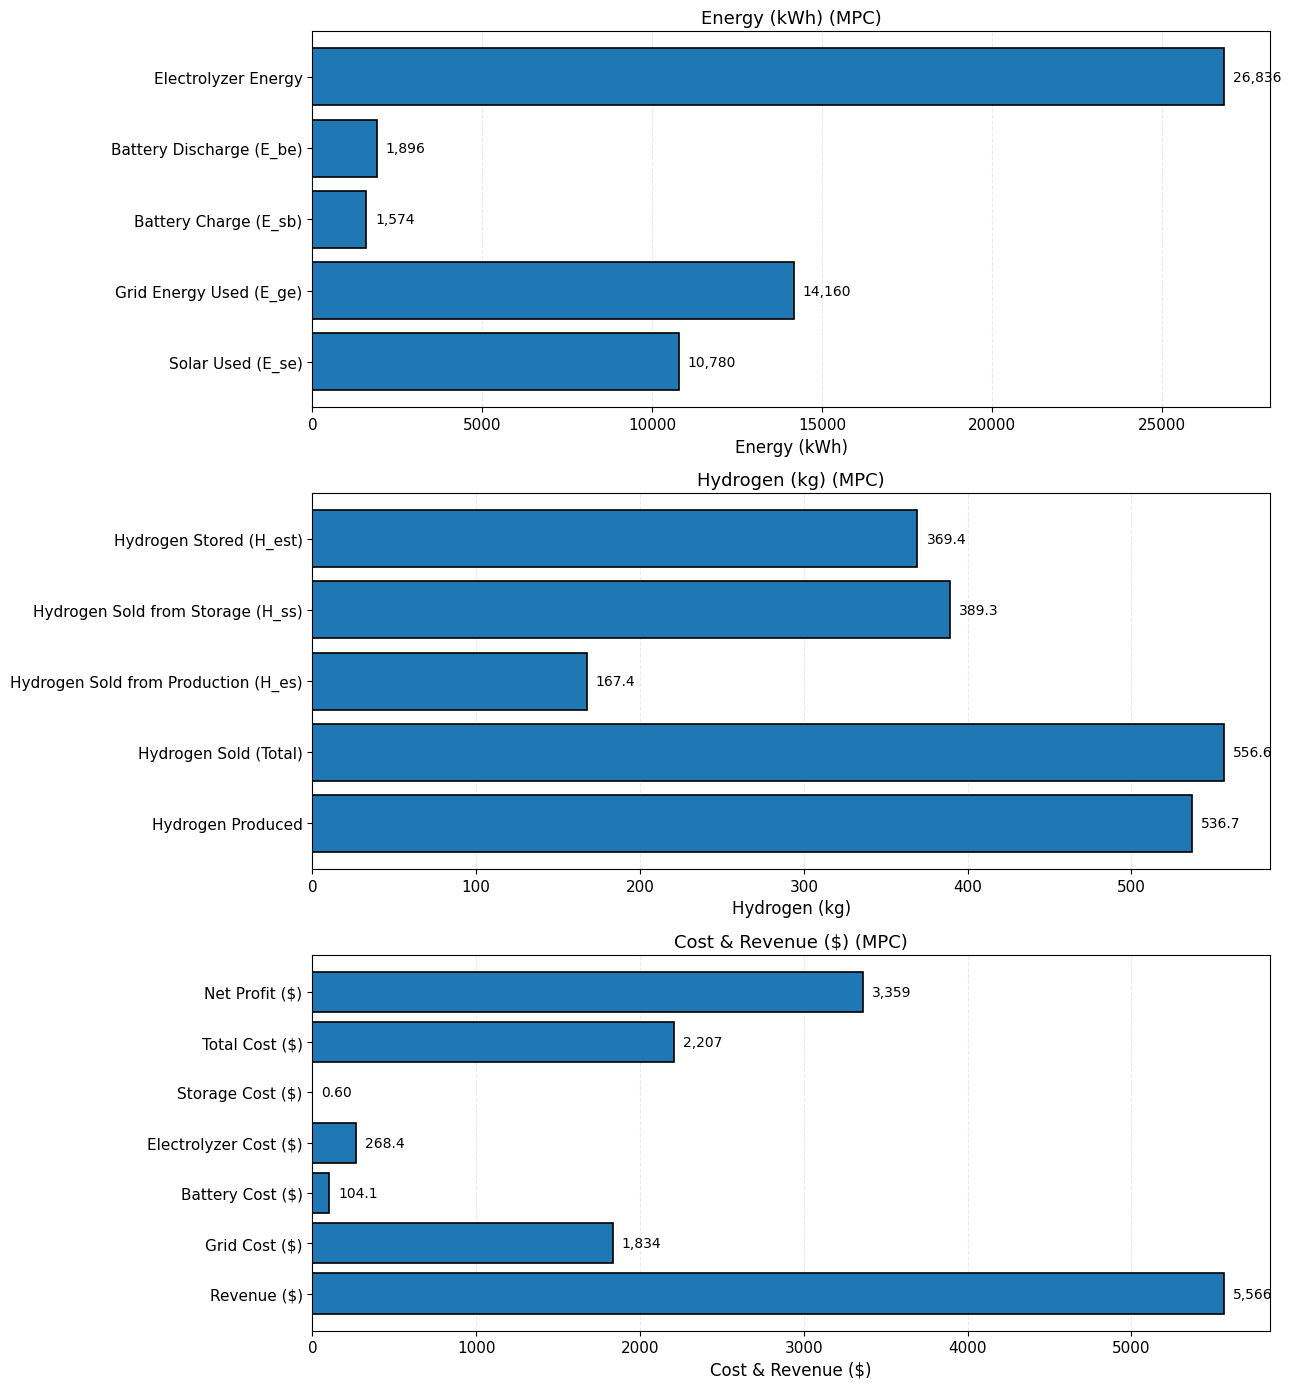

In [6]:
# Example usage:
logs_mpc, kpis_mpc = demo_mpc(seed=0, solver_name="cplex", tee=False)

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fig6_mpc_timeseries(logs_mpc, savepath=None, show=True):
    """
    Plot Figure 6: Time-series operational behavior under MPC.
    """

    t = np.arange(len(logs_mpc["P_elec"]))

    solar = np.asarray(logs_mpc["solar"], dtype=float)
    P_elec = np.asarray(logs_mpc["P_elec"], dtype=float)
    E_ge   = np.asarray(logs_mpc["E_ge"], dtype=float)
    SOC    = np.asarray(logs_mpc["SOC"], dtype=float)
    H_store= np.asarray(logs_mpc["H_store"], dtype=float)

    price = np.array([real_grid_price(int(k)) for k in t], dtype=float)

    # Color palette (same as RBC for consistency)
    COL_SOLAR = "#1f77b4"
    COL_PRICE = "#ff7f0e"
    COL_ELEC  = "#2ca02c"
    COL_GRID  = "#d62728"
    COL_SOC   = "#9467bd"
    COL_H2    = "#8c564b"

    fig, axs = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
    fig.suptitle("Figure 6. MPC time-series operational behavior", y=0.98)

    # -------------------------
    # (a) Solar + Price
    # -------------------------
    ax = axs[0]
    l1 = ax.plot(t, solar, color=COL_SOLAR, linewidth=2.2,
                 label="Solar availability $S_t$ [kW]")
    ax.set_ylabel("Solar [kW]")
    ax.grid(True, alpha=0.2, linestyle="--")

    ax_r = ax.twinx()
    l2 = ax_r.plot(t, price, color=COL_PRICE, linestyle="--", linewidth=2.0,
                   label="Grid price $\\pi_t$ [$/kWh]")
    ax_r.set_ylabel("Price [$/kWh]")

    # -------------------------
    # (b) Electrolyzer + Grid
    # -------------------------
    ax = axs[1]
    l3 = ax.plot(t, P_elec, color=COL_ELEC, linewidth=2.4,
                 label="Electrolyzer power $P_{e,t}$ [kW]")
    l4 = ax.plot(t, E_ge, color=COL_GRID, linestyle="--", linewidth=2.0,
                 label="Grid→Electrolyzer $E_{ge,t}$ [kW]")
    ax.set_ylabel("Power [kW]")
    ax.grid(True, alpha=0.2, linestyle="--")

    # -------------------------
    # (c) SOC + H2 storage
    # -------------------------
    ax = axs[2]
    l5 = ax.plot(t, SOC, color=COL_SOC, linewidth=2.0,
                 label="Battery SOC [kWh]")
    ax.set_ylabel("SOC [kWh]")
    ax.grid(True, alpha=0.2, linestyle="--")

    ax_r = ax.twinx()
    l6 = ax_r.plot(t, H_store, color=COL_H2, linestyle="--", linewidth=2.0,
                   label="H$_2$ storage $H_t$ [kg]")
    ax_r.set_ylabel("H$_2$ storage [kg]")

    axs[2].set_xlabel("Time step $t$ [hour]")

    # -------------------------
    # Global legend outside
    # -------------------------
    lines = l1 + l2 + l3 + l4 + l5 + l6
    labels = [line.get_label() for line in lines]

    fig.legend(lines, labels,
               loc="center left",
               bbox_to_anchor=(1.02, 0.5),
               frameon=False)

    plt.tight_layout(rect=[0, 0, 0.85, 1])

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    if show:
        plt.show()

    plt.close(fig)

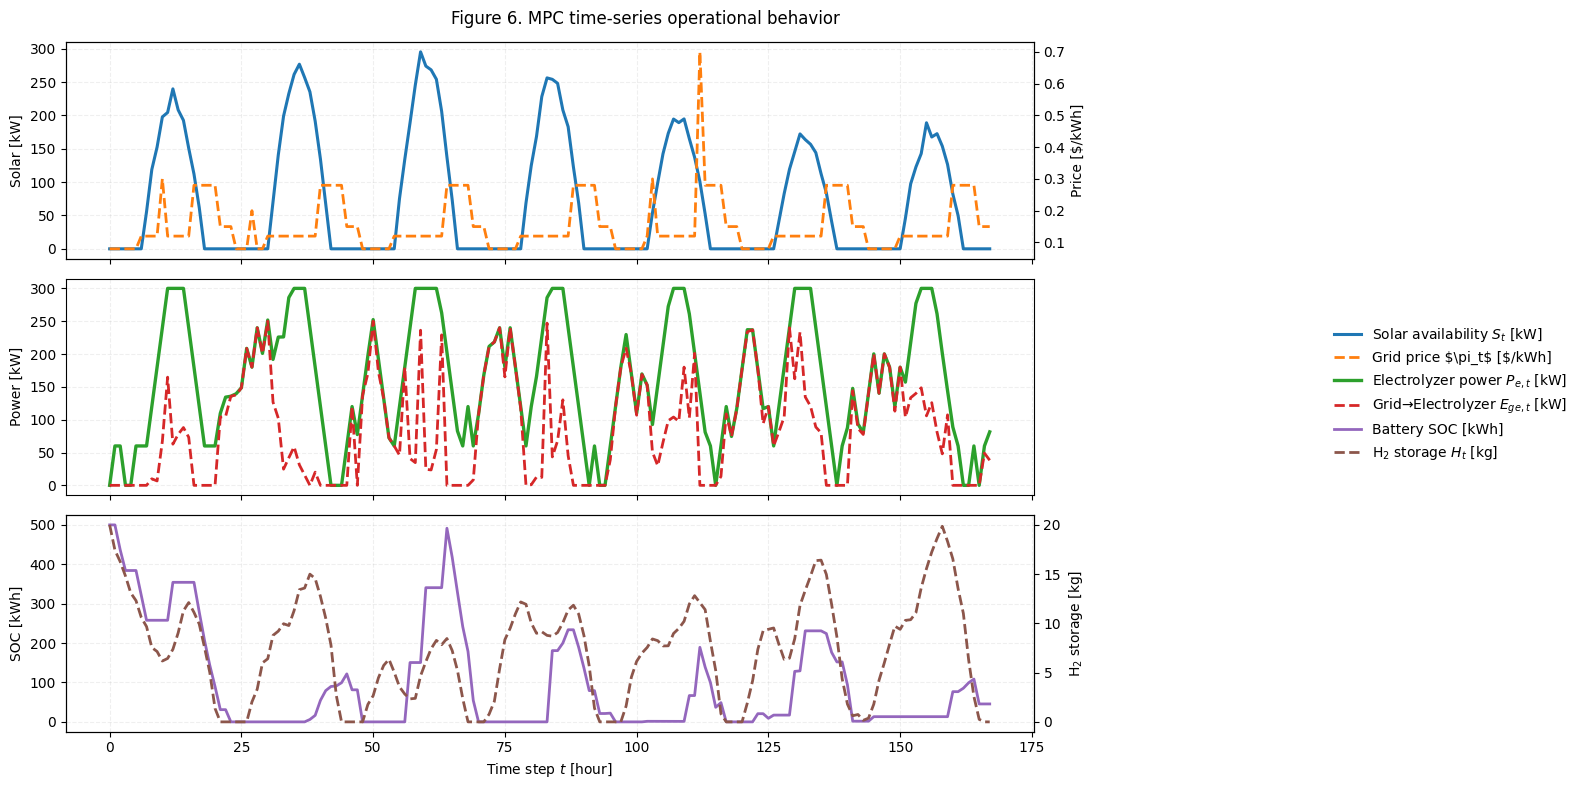

In [10]:
plot_fig6_mpc_timeseries(logs_mpc)